Connected to Python 3.11.0

In [ ]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from sklearn.metrics import mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
SYMBOL = "AAPL"
START_DATE = "2023-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")
client = StockHistoricalDataClient("PKMHUX5TXYAFWCSX6GTZC3NLEL",  "5mDe8bx2qEx2AQ7p7PxkKicewWYi1YG5Px1h6sR8xGXs")

request_params = StockBarsRequest(
    symbol_or_symbols=SYMBOL,
    start=START_DATE,
    end=END_DATE,
    timeframe=TimeFrame.Day
)

bars = client.get_stock_bars(request_params)
df = bars.df.reset_index()

df = df[["timestamp", "open", "high", "low", "close", "volume"]]

df["returns"] = df["close"].pct_change()
df["volatility"] = df["returns"].rolling(window=5).std()
df["ma_5"] = df["close"].rolling(window=5).mean()
df["ma_10"] = df["close"].rolling(window=10).mean()
df["ma_20"] = df["close"].rolling(window=20).mean()

df["target"] = df["close"].shift(-1)
df = df.dropna()

features = ["close", "volume", "volatility", "ma_5", "ma_10", "ma_20"]

X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: ${mae:.2f}")

Mean Absolute Error: $2.40


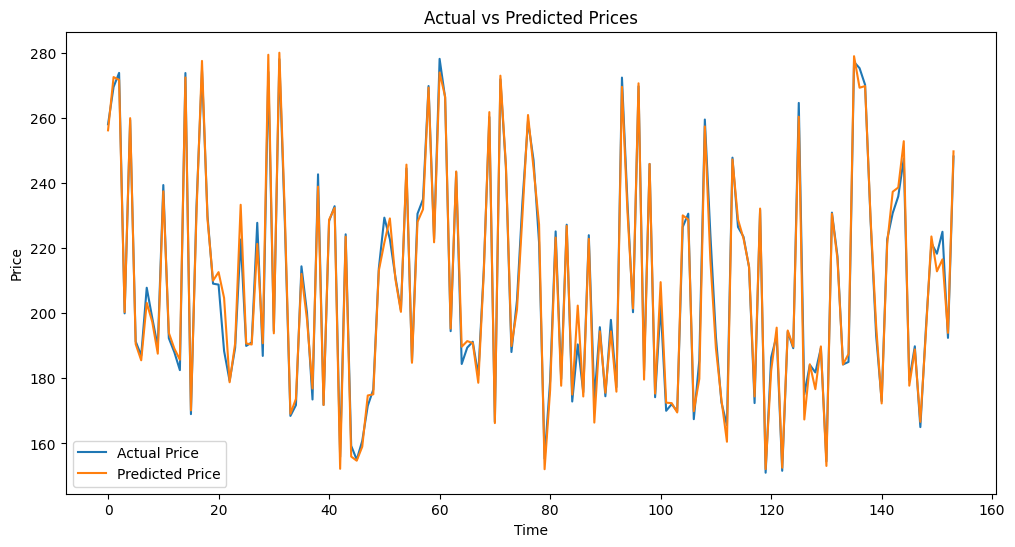

Next Dayn Price For Apple: $273.30


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

latest_data = X.iloc[-1:].values
latest_prediction = model.predict(latest_data)[0]
print(f"Next Dayn Price For Apple: ${latest_prediction:.2f}")

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd


price_data = df[["timestamp", "close"]].copy()
price_data = price_data.rename(columns={"timestamp": "ds", "close": "y"})
price_data["ds"] = pd.to_datetime(price_data["ds"]).dt.tz_localize(None)

Importing plotly failed. Interactive plots will not work.


In [ ]:
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
m.fit(price_data)


future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)


tomorrow = forecast[forecast["ds"] > price_data["ds"].max()].iloc[0]
tomorrow_date = tomorrow["ds"].strftime("%Y-%m-%d")
tomorrow_price = tomorrow["yhat"]

15:09:48 - cmdstanpy - INFO - Chain [1] start processing
15:09:48 - cmdstanpy - INFO - Chain [1] done processing


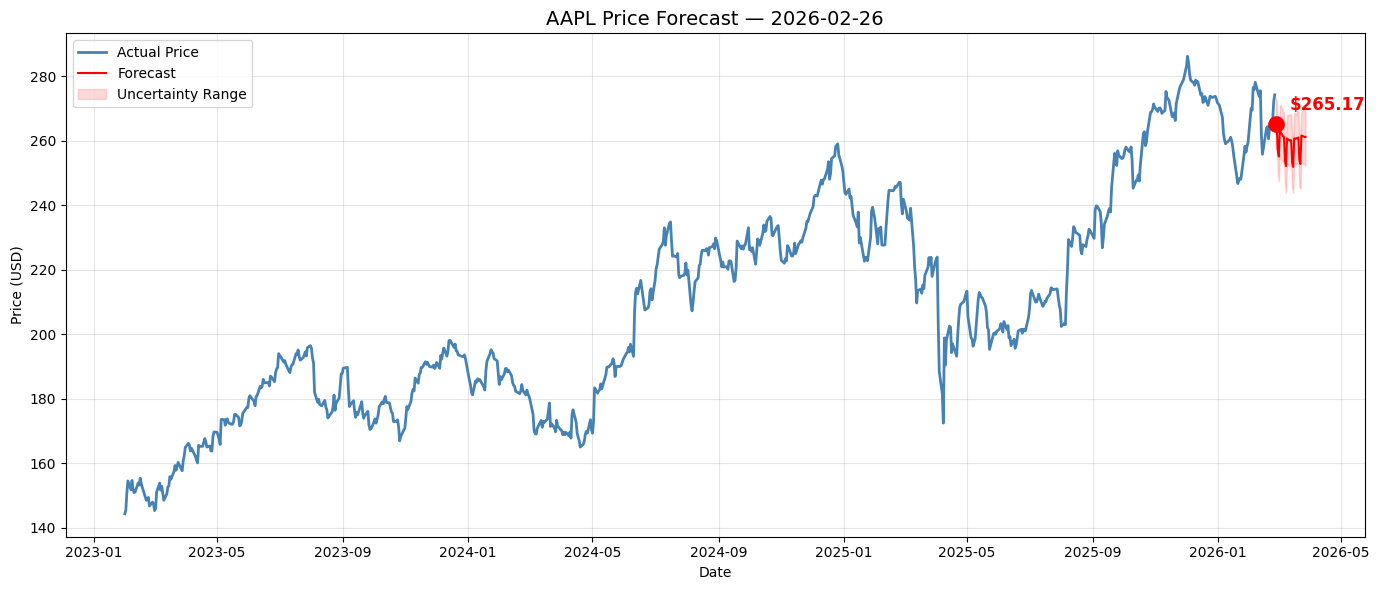

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(price_data["ds"], price_data["y"], color="steelblue", linewidth=2, label="Actual Price")

future_only = forecast[forecast["ds"] > price_data["ds"].max()]
ax.plot(future_only["ds"], future_only["yhat"], color="red", label="Forecast")
ax.fill_between(future_only["ds"], future_only["yhat_lower"], future_only["yhat_upper"],
                color="red", alpha=0.15, label="Uncertainty Range")

ax.scatter(tomorrow["ds"], tomorrow_price, color="red", s=120, zorder=5)
ax.annotate(f"${tomorrow_price:.2f}", xy=(tomorrow["ds"], tomorrow_price),
            xytext=(10, 10), textcoords="offset points",
            fontsize=12, color="red", fontweight="bold")

ax.set_title(f"{SYMBOL} Price Forecast — {tomorrow_date}", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Predicted close for {tomorrow_date}: ${tomorrow_price:.2f}")
print(f"Range: ${tomorrow['yhat_lower']:.2f} – ${tomorrow['yhat_upper']:.2f}")

Predicted close for 2026-02-26: $265.17
Range: $257.44 – $273.29


In [ ]:
predictions = []
for i in range(100):
    noise = price_data.copy()
    noise["y"] = noise["y"] * (1 + np.random.normal(0, 0.01, len(noise)))  
    m_sim = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    m_sim.fit(noise)
    fc_sim = m_sim.predict(m_sim.make_future_dataframe(periods=30))
    predictions.append(fc_sim[fc_sim["ds"] > price_data["ds"].max()].iloc[0]["yhat"])

print(f"Mean: ${np.mean(predictions):.2f}")
print(f"Std Dev: ${np.std(predictions):.2f}")
print(f"Range: ${np.min(predictions):.2f} – ${np.max(predictions):.2f}")

15:10:03 - cmdstanpy - INFO - Chain [1] start processing
15:10:03 - cmdstanpy - INFO - Chain [1] done processing
15:10:03 - cmdstanpy - INFO - Chain [1] start processing
15:10:03 - cmdstanpy - INFO - Chain [1] done processing
15:10:03 - cmdstanpy - INFO - Chain [1] start processing
15:10:03 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1] done processing
15:10:04 - cmdstanpy - INFO - Chain [1] start processing
15:10:04 - cmdstanpy - INFO - Chain [1]

Mean: $266.44
Std Dev: $0.80
Range: $264.48 – $268.67


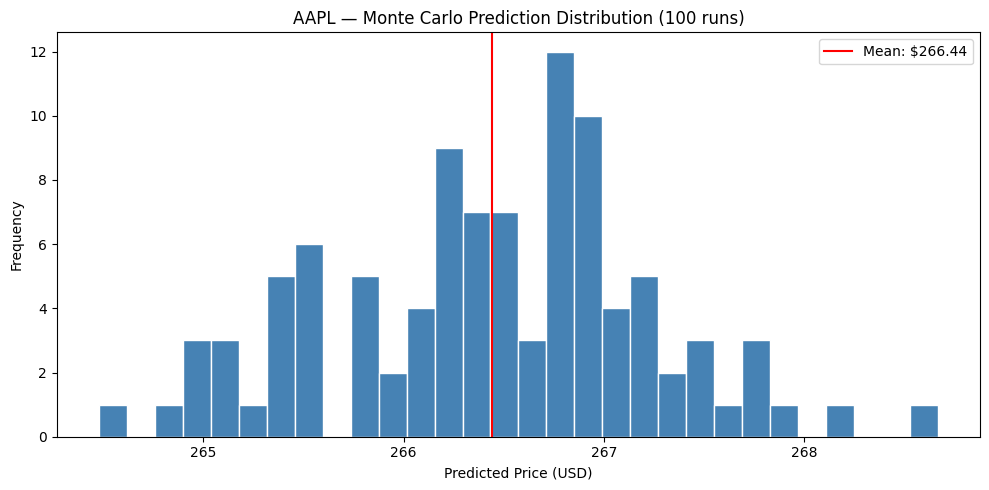

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(predictions, bins=30, color="steelblue", edgecolor="white")
plt.axvline(np.mean(predictions), color="red", label=f"Mean: ${np.mean(predictions):.2f}")
plt.title(f"{SYMBOL} — Monte Carlo Prediction Distribution (100 runs)")
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()